# FMCG Distribution Analysis
## Python Project

This project analyzes product distribution across outlets using Python, Pandas, and Matplotlib.


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1. Creating a dataset

In [47]:
data = {
    'Product': ['Beer A', 'Beer B', 'Cider A', 'Cider B', 'Soft Drink A', 'Soft Drink B', 'Water', 'Energy Drink'],
    'Category': ['Beer', 'Beer', 'Cider', 'Cider', 'Soft Drink', 'Soft Drink', 'Water', 'Energy Drink'],
    'Outlets_Targeted': [500, 500, 450, 450, 600, 600, 550, 400],
    'Outlets_With_Product': [125, 350, 315, 170, 510, 420, 595, 260]
}

df = pd.DataFrame(data)
df

,Product,Category,Outlets_Targeted,Outlets_With_Product
0,Beer A,Beer,500,125
1,Beer B,Beer,500,350
2,Cider A,Cider,450,315
3,Cider B,Cider,450,170
4,Soft Drink A,Soft Drink,600,510
5,Soft Drink B,Soft Drink,600,420
6,Water,Water,550,595
7,Energy Drink,Energy Drink,400,260


## 2. Calculate distribution percentage

In [48]:
df['Distribution_%'] = (df['Outlets_With_Product'] / df['Outlets_Targeted']) * 100
df['Distribution_%'] = df['Distribution_%'].round(2)
df

,Product,Category,Outlets_Targeted,Outlets_With_Product,Distribution_%
0,Beer A,Beer,500,125,25.00
1,Beer B,Beer,500,350,70.00
2,Cider A,Cider,450,315,70.00
3,Cider B,Cider,450,170,37.78
4,Soft Drink A,Soft Drink,600,510,85.00
5,Soft Drink B,Soft Drink,600,420,70.00
6,Water,Water,550,595,108.18
7,Energy Drink,Energy Drink,400,260,65.00


## 3.1 Find products with the highest distribution


In [49]:
df.sort_values('Distribution_%', ascending=False)[['Product', 'Distribution_%']]

,Product,Distribution_%
6,Water,108.18
4,Soft Drink A,85.00
1,Beer B,70.00
2,Cider A,70.00
5,Soft Drink B,70.00
7,Energy Drink,65.00
3,Cider B,37.78
0,Beer A,25.00


## 3.2 List the Bottom 3 performing distribution products

In [50]:
df.sort_values('Distribution_%', ascending=True)[['Product', 'Distribution_%']].head(3)

,Product,Distribution_%
0,Beer A,25.00
3,Cider B,37.78
7,Energy Drink,65.00


## 3.3 List the top 3 performing distribution products

In [37]:
df.sort_values('Distribution_%', ascending=False)[['Product', 'Distribution_%']].head(3)

,Product,Distribution_%
6,Water,108.18
4,Soft Drink A,85.00
1,Beer B,70.00


## 4. Find products below 70% distribution


In [51]:
low_distribution = df[df['Distribution_%'] < 70]
low_distribution[['Product', 'Distribution_%']]

,Product,Distribution_%
0,Beer A,25.00
3,Cider B,37.78
7,Energy Drink,65.00


## 5. Average distribution by category


In [52]:
category_distribution = df.groupby('Category')['Distribution_%'].mean().round(2).sort_values(ascending=False)
category_distribution

Category
Water           108.18
Soft Drink       77.50
Energy Drink     65.00
Cider            53.89
Beer             47.50
Name: Distribution_%, dtype: float64

## 6. Overall distribution


In [53]:
total_targeted = df['Outlets_Targeted'].sum()
total_distribution = df['Outlets_With_Product'].sum()
overall_distribution = (total_distribution / total_targeted) * 100

print('Total outlets targeted:', total_targeted)
print('Total product placements:', total_distribution)
print('Overall distribution:', round(overall_distribution, 2), '%')

Total outlets targeted: 4050
Total product placements: 2745
Overall distribution: 67.78 %


## 7. Distribution chart


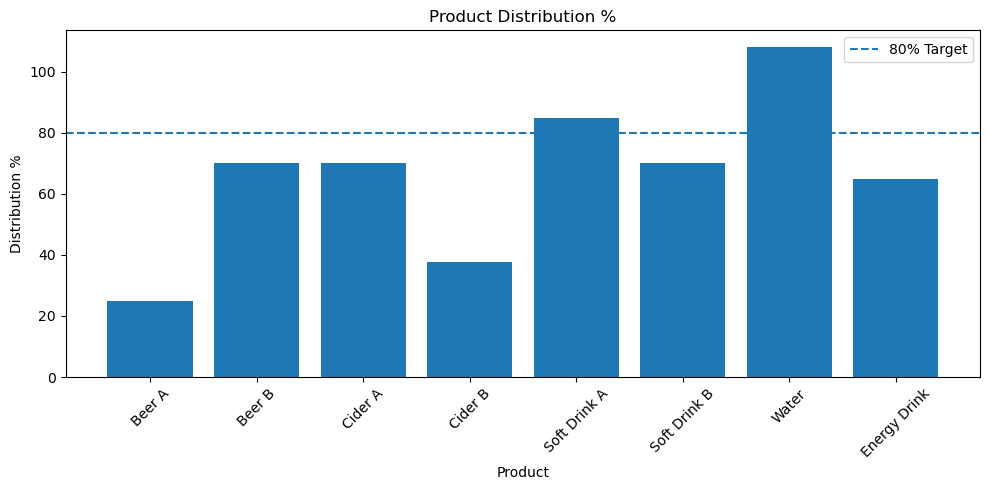

In [58]:
plt.figure(figsize=(10, 5))
plt.bar(df['Product'], df['Distribution_%'])
plt.axhline(80, linestyle='--', label='80% Target')
plt.title('Product Distribution %')
plt.xlabel('Product')
plt.ylabel('Distribution %')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<Axes: xlabel='Product', ylabel='Distribution_%'>

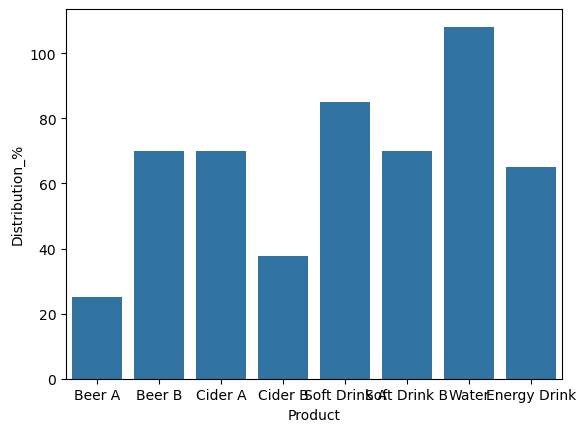

In [59]:
import seaborn as sns

sns.barplot(
    data=df,
    x='Product',
    y='Distribution_%'
)

## 8. Category chart


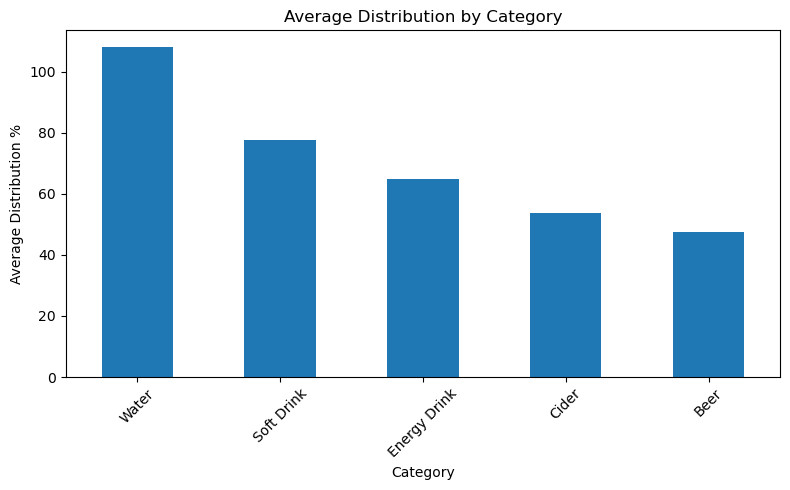

In [56]:
category_distribution.plot(kind='bar', figsize=(8, 5))
plt.title('Average Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Average Distribution %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()